In [214]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [215]:
btc_data = pd.read_csv("./dataset/portfolio_data.csv")

In [216]:
btc_data = btc_data.drop(["AMZN", "DPZ", "NFLX"], axis=1)

In [217]:
btc_data.head()

,Date,BTC
0,5/1/2013,106.250000
1,5/2/2013,98.099998
2,5/3/2013,112.900002
3,5/6/2013,109.599998
4,5/7/2013,113.199997


In [218]:
btc_data.shape

(1520, 2)

In [219]:
btc_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1520 non-null   str    
 1   BTC     1520 non-null   float64
dtypes: float64(1), str(1)
memory usage: 23.9 KB


In [220]:
btc_data.isnull().sum()

Date    0
BTC     0
dtype: int64

In [221]:
btc_data.duplicated().sum()

np.int64(0)

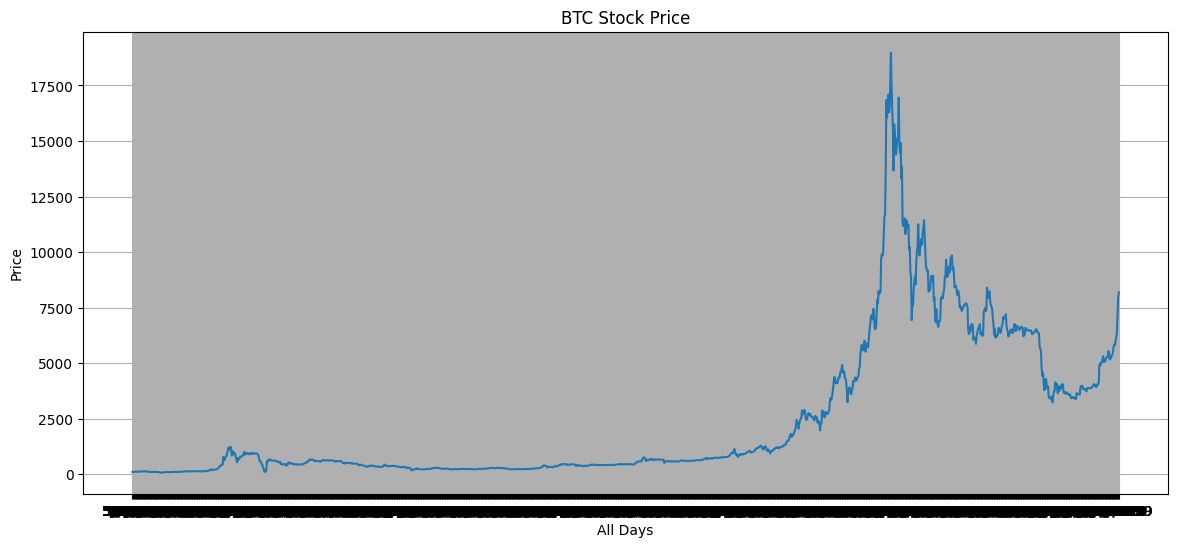

In [222]:
plt.figure(figsize=(14, 6))
plt.plot(btc_data['Date'], btc_data['BTC'])
plt.title("BTC Stock Price")
plt.xlabel("All Days")
plt.ylabel("Price")
plt.grid()
plt.show()

In [223]:
btc_price = btc_data["BTC"].values
print(type(btc_price))

<class 'numpy.ndarray'>


In [224]:
# time_window
X = []
y = []
input_window = 60
output_window = 2
# N(Data) - input_window - output_window + 1
print(len(btc_price) - input_window - output_window + 1)

1459


In [225]:
counter = 0
for index in range(len(btc_price) - input_window - output_window + 1):
    start_index = index
    end_index = index + input_window
    counter += 1
    if counter < 10:
        print(f"x_start_index: {start_index} - x_end_index: {end_index - output_window} - y_index: {end_index}")
    X.append(btc_price[start_index : end_index])
    y.append(btc_price[end_index])

x_start_index: 0 - x_end_index: 58 - y_index: 60
x_start_index: 1 - x_end_index: 59 - y_index: 61
x_start_index: 2 - x_end_index: 60 - y_index: 62
x_start_index: 3 - x_end_index: 61 - y_index: 63
x_start_index: 4 - x_end_index: 62 - y_index: 64
x_start_index: 5 - x_end_index: 63 - y_index: 65
x_start_index: 6 - x_end_index: 64 - y_index: 66
x_start_index: 7 - x_end_index: 65 - y_index: 67
x_start_index: 8 - x_end_index: 66 - y_index: 68


In [226]:
print(len(X))
print(len(y))

1459
1459


In [227]:
#Do not shuffle the original time series data. After creating sliding windows,
# you can shuffle the training samples before training the model.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [228]:
print(type(X_train))
print(type(y_train))

<class 'list'>
<class 'list'>


In [229]:
from sklearn.preprocessing import MinMaxScaler

data_scaler = MinMaxScaler()
X_train_nor = data_scaler.fit_transform(X_train)
y_test_nor = data_scaler.transform(X_test)

target_scaler = MinMaxScaler()
y_train_nor = target_scaler.fit_transform((np.reshape(y_train, (-1, 1))))
y_test_nor = target_scaler.transform(np.reshape(y_test, (-1, 1)))